# Intelligent Agents, Graph Search, and Route Planning

### Lecture 1-1: A* search for shortest-route planning using NetworkX and OpenStreetMap data

**Unit 1**

1.1 Agents and environments  
1.2 State-space modeling  
1.3 Graph search algorithms  
1.4 Heuristic search with A*

**Libraries:** `NetworkX`, `OSMnx`, `heapq`, `matplotlib`

**Datasets:** OpenStreetMap, campus transportation networks

---

### Learning goals

By the end of this notebook, you should be able to:

- explain what an **intelligent agent** is in a route-planning problem;
- represent a real problem as a **state-space model**;
- distinguish **uninformed** from **informed** search;
- explain BFS, DFS, Uniform-Cost Search, Greedy Best-First Search, and A*;
- explain what a **heuristic** is;
- use NetworkX to represent and search graphs;
- use OpenStreetMap + OSMnx to build a real geographic graph;
- build a route planner with A* and a custom cost.

> **Central idea:** We are not learning Python for its own sake. Python is the tool we use to make the search problem visible.

## 0. The problem: getting from A to B

Imagine a delivery robot on a university campus.

It knows:

- where it is,
- where it needs to go,
- which paths connect different locations,
- and the cost of moving along each path.

Its task is:

> **Find a sequence of actions that takes it from the start to the goal.**

This sounds easy. But a large environment may contain thousands of possible locations and an enormous number of possible routes.

That is where **search algorithms** become useful.

# 1.1 Agents and environments

An **agent** is a system that:

1. perceives its environment,
2. chooses actions,
3. acts to achieve a goal.

For route planning:

| Concept | Example |
|---|---|
| Agent | Delivery robot |
| Environment | Campus paths |
| State | Robot's current location |
| Action | Move to a neighboring location |
| Goal | Reach the laboratory |
| Cost | Distance, time, energy, risk, etc. |

A search algorithm is **not the robot**. It is a procedure used to decide which possible actions/routes should be considered.

### A useful way to think about an agent

```text
             ENVIRONMENT
                  │
             perception
                  ▼
             ┌─────────┐
             │  AGENT  │
             └─────────┘
                  │
                action
                  ▼
             ENVIRONMENT
```

For route planning, the agent might repeatedly:

> "I am here. What can I do next? Which option is most promising?"

### Real example

A campus robot must go from the library to a laboratory.

There may be many alternatives:

```text
                 ┌── C ───────┐
                 │            │
Library ── A ─── B ────────────┤── Lab
                 │            │
                 └── D ───────┘
```

The AI problem is not simply **drawing a route**.

It is deciding:

> **Which sequence of actions should the agent choose?**

# 1.2 State-space modeling

Before choosing an algorithm, we need a **model of the problem**.

A search algorithm searches the representation we give it.

A route-planning problem can be described with:

- **States** — where the agent can be.
- **Actions** — what the agent can do.
- **Transition model** — what state results from an action.
- **Goal test** — whether the destination has been reached.
- **Path cost** — how expensive a route is.

A compact mathematical description is:

\[
(S,A,T,s_0,G,C)
\]

where:

- \(S\): possible states
- \(A\): actions
- \(T\): transitions
- \(s_0\): initial state
- \(G\): goal
- \(C\): cost

### From a map to a graph

For route planning, we can model:

- **nodes** → intersections or locations;
- **edges** → roads or paths;
- **edge weights** → distance, time, energy, etc.

```text
        B
       / \
      /   \
     A     D
      \   /
       \ /
        C
```

The same idea appears in:

- road navigation,
- logistics,
- warehouse robots,
- public transportation,
- games,
- robotic motion planning,
- network routing.

The graph is our **model of the environment**.

In [1]:
%pip install networkx matplotlib osmnx scikit-learn

Note: you may need to restart the kernel to use updated packages.


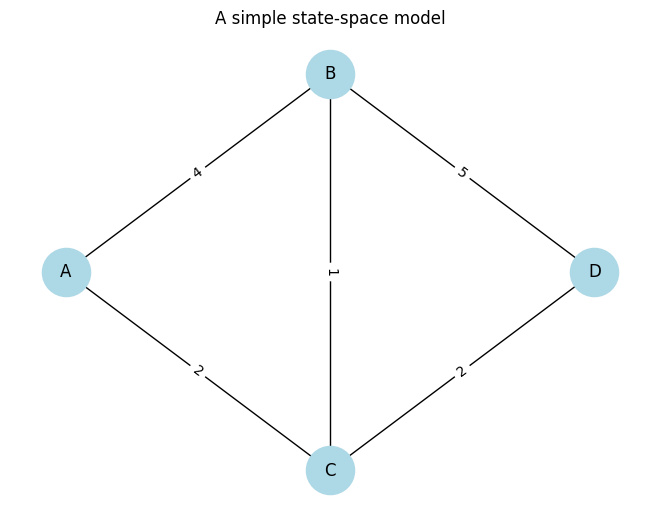

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_weighted_edges_from([
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "D", 5),
    ("C", "D", 2),
    ("B", "C", 1),
])

pos = {
    "A": (0, 0),
    "B": (1, 1),
    "C": (1, -1),
    "D": (2, 0),
}

nx.draw(G, pos, with_labels=True, node_size=1200, node_color="lightblue")
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=nx.get_edge_attributes(G, "weight")
)
plt.title("A simple state-space model")
plt.axis("off")
plt.show()

### Think before running more code

In the graph above:

1. What is a **state**?
2. What is an **action**?
3. What does an edge weight represent?
4. What is the goal if we travel from A to D?

Notice that the graph can remain the same while the meaning of "best" changes:

- shortest distance,
- shortest time,
- lowest energy,
- safest route.

The **cost function** defines what we mean by "best".

# 1.3 Graph search algorithms

Now we have a model. The next question is:

> **How do we search the graph?**

There are two important families for this unit.

### Uninformed search

No estimate of the remaining distance/cost is used.

- BFS
- DFS
- Uniform-Cost Search

### Informed search

The algorithm receives additional guidance in the form of a **heuristic**.

- Greedy Best-First Search
- A*

> **Informed does not mean "knows the answer". It means "has useful information that helps guide the search."**

## BFS — Breadth-First Search

BFS explores level by level.

```text
             Start
            /     \
           A       B
         /  \     / \
        C    D   E   F
```

It explores:

```text
Start
A, B
C, D, E, F
...
```

If every step has the same cost, BFS finds a path with the **fewest number of edges**.

Think:

> **"Explore everything one step away before going two steps away."**

## DFS — Depth-First Search

DFS goes as deep as possible before backtracking.

Think:

> **"Follow one possibility as far as you can, then come back."**

DFS is useful for many graph problems, but it is not generally a shortest-path algorithm.

This gives us an important distinction:

> **Finding a solution is not the same as finding the best solution.**

## Uniform-Cost Search

What if edges have different costs?

```text
A ──1── B ──10── Goal

A ──4── C ── 2── Goal
```

The first route costs 11.

The second route costs 6.

Uniform-Cost Search prioritizes the state with the smallest cost already paid:

\[
f(n)=g(n)
\]

where \(g(n)\) is the cost from the start to node \(n\).

This is closely related to the shortest-path algorithms you may have already encountered in other courses.

In [3]:
path = nx.shortest_path(G, source="A", target="D", weight="weight")
cost = nx.shortest_path_length(G, source="A", target="D", weight="weight")

print("Shortest path:", path)
print("Total cost:", cost)

Shortest path: ['A', 'C', 'D']
Total cost: 4


## The key question

Suppose the goal is somewhere to the right.

Wouldn't it be useful to tell the algorithm:

> **"States that appear closer to the goal are probably more promising."**

Yes.

That extra information is the **heuristic**.

# 1.4 Heuristic search with A*

## What is a heuristic?

A heuristic is simply:

> **an estimate of the remaining cost from a state to the goal.**

We write:

\[
h(n)
\]

For a grid, one possible heuristic is Manhattan distance:

\[
h(n)=|x_n-x_g|+|y_n-y_g|
\]

For geographic route planning, a natural heuristic is **straight-line distance** to the destination.

The heuristic does **not** tell us the actual route.

It gives the algorithm a useful estimate:

> **"How promising is this state?"**

## Greedy Best-First Search

One strategy is to use only the heuristic:

\[
f(n)=h(n)
\]

The algorithm effectively says:

> "Choose the state that looks closest to the goal."

This can be fast, but it can make bad decisions.

A state may appear very close to the goal while a wall, river, one-way street, or restricted path prevents a direct route.

So:

> **A heuristic is guidance, not the solution itself.**

# A* — the central idea

A* combines:

\[
\boxed{f(n)=g(n)+h(n)}
\]

where:

- \(g(n)\) = actual cost already paid;
- \(h(n)\) = estimated cost remaining;
- \(f(n)\) = estimated total cost of a solution through \(n\).

Think:

```text
PAST COST                 FUTURE ESTIMATE
    │                           │
    ▼                           ▼
   g(n)          +             h(n)
    └───────────────┬───────────┘
                    ▼
                  f(n)
```

A* balances **what we have already spent** with **where we appear to be going**.

### Numerical example

Suppose A* is considering two states:

| State | \(g(n)\) | \(h(n)\) | \(f(n)\) |
|---|---:|---:|---:|
| A | 4 | 10 | 14 |
| B | 7 | 5 | 12 |

A* prefers B:

\[
f(B)=7+5=12 < 14=f(A)
\]

Notice:

- A is cheaper so far;
- B looks better overall.

That is why A* is different from simply choosing the closest-looking node.

## When can A* guarantee an optimal route?

A central idea is an **admissible heuristic**.

It must not overestimate the true minimum remaining cost:

\[
h(n)\leq h^*(n)
\]

For physical-distance road routing, straight-line distance is often a safe lower-bound estimate because a road route cannot normally be shorter than the direct distance between two points.

A heuristic does **not** need to be perfect.

It needs to provide useful guidance while respecting the conditions required for the guarantee we want.

# 2. A real environment: OpenStreetMap

Our toy graph was created manually.

Real applications can obtain geographic data from **OpenStreetMap**.

OSMnx can convert OpenStreetMap data into a NetworkX graph.

```text
OpenStreetMap
      ↓
     OSMnx
      ↓
NetworkX graph
      ↓
      A*
      ↓
Real route
```

This is where state-space modeling becomes a real application.

## Install the libraries

If necessary, install:

```bash
pip install osmnx networkx matplotlib
```

OpenStreetMap queries require an internet connection.

The small graph examples above do not.

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import heapq

print("NetworkX:", nx.__version__)

try:
    import osmnx as ox
    print("OSMnx:", ox.__version__)
except ImportError:
    print("OSMnx is not installed.")

NetworkX: 3.2.1
OSMnx: 2.0.7


/Users/eugenio/Documents/ArtificialIntelligence/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Download a small real network

The example below uses an area around Yachay Tech.

The coordinates are only an example. In the assignment, you will choose your own area.

We use `walk` because the assignment is a campus/pedestrian route-planning exercise.

In [14]:
import osmnx as ox

center_point = (0.4037, -78.1740)

# A larger radius covers more streets/paths, giving the route more intersections to choose from.
G_osm = ox.graph.graph_from_point(
    center_point,
    dist=2500,
    network_type="walk",
    simplify=True
)

print("Nodes:", len(G_osm.nodes))
print("Edges:", len(G_osm.edges))

Nodes: 206
Edges: 582


## Choose start and goal

A user normally gives us geographic coordinates, not an internal graph node ID.

OSMnx can find the graph node closest to each coordinate.

In [16]:
# Replace these with two points in the downloaded area.
# Pick points that are far apart so the route crosses several intersections.

start_latlon = (0.4037, -78.1740)
goal_latlon  = (0.3960, -78.1630)

start_node = ox.distance.nearest_nodes(
    G_osm, X=start_latlon[1], Y=start_latlon[0]
)

goal_node = ox.distance.nearest_nodes(
    G_osm, X=goal_latlon[1], Y=goal_latlon[0]
)

print("Start node:", start_node)
print("Goal node:", goal_node)

Start node: 8360821169
Goal node: 2760059859


## Shortest route by physical distance

OpenStreetMap edges commonly contain a `length` attribute measured in meters.

So we can define:

\[
cost(edge)=length(edge)
\]

and ask for the minimum-distance route.

In [17]:
route = nx.astar_path(
    G_osm,
    start_node,
    goal_node,
    heuristic=None,
    weight="length"
)

distance_m = nx.astar_path_length(
    G_osm,
    start_node,
    goal_node,
    heuristic=None,
    weight="length"
)

print("Route nodes:", len(route))
print(f"Distance: {distance_m:.1f} m")

Route nodes: 9
Distance: 2833.8 m


### Why explicitly build a heuristic?

The point of today's class is to understand **informed search**.

Each OSM node has:

- `x` = longitude
- `y` = latitude

We can estimate remaining physical distance using the straight-line geographic distance from a node to the goal.

That becomes our \(h(n)\).

In [18]:
def geographic_heuristic(u, v):
    """Straight-line distance in meters between two OSM nodes."""
    u_lat, u_lon = G_osm.nodes[u]["y"], G_osm.nodes[u]["x"]
    v_lat, v_lon = G_osm.nodes[v]["y"], G_osm.nodes[v]["x"]

    return ox.distance.great_circle(
        u_lat, u_lon, v_lat, v_lon
    )


route_astar = nx.astar_path(
    G_osm,
    start_node,
    goal_node,
    heuristic=geographic_heuristic,
    weight="length"
)

astar_distance_m = nx.path_weight(
    G_osm, route_astar, weight="length"
)

print("Route nodes:", len(route_astar))
print(f"A* route distance: {astar_distance_m:.1f} m")

Route nodes: 9
A* route distance: 2833.8 m


## Visualize the route

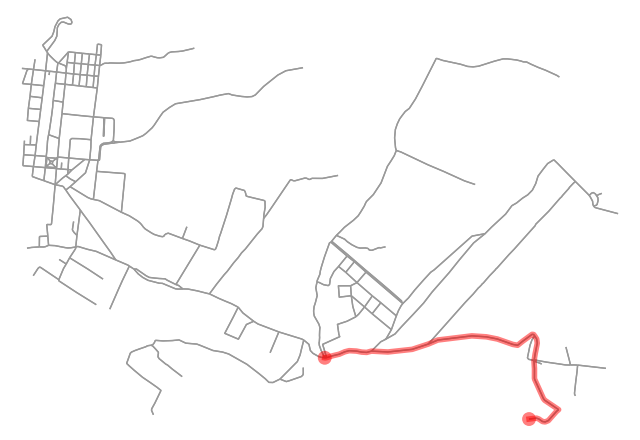

In [19]:
fig, ax = ox.plot_graph_route(
    G_osm,
    route_astar,
    route_color="red",
    route_linewidth=4,
    node_size=0,
    bgcolor="white"
)
plt.show()

### The complete real-world pipeline

```text
START + GOAL
     ↓
Latitude / longitude
     ↓
OpenStreetMap
     ↓
OSMnx
     ↓
NetworkX graph
     ↓
A*
     ↓
h(n) = straight-line distance
     ↓
Route
```

The toy grid and the real map are the **same AI problem at different scales**.

# 3. Custom costs

The shortest route is not always the best route.

For a campus robot, for example, we might care about:

- distance,
- stairs,
- steep paths,
- accessibility,
- safety,
- energy consumption.

So instead of:

\[
cost=distance
\]

we could define:

\[
cost=distance+penalty
\]

For example, a 100 m undesirable segment could have:

\[
100+300=400
\]

The search algorithm can then prefer a physically longer but otherwise better route.

In [10]:
# Inspect attributes available in a few OpenStreetMap edges.

for u, v, data in list(G_osm.edges(data=True))[:5]:
    print("\n", u, "->", v)
    print({
        k: data[k]
        for k in data
        if k in ["length", "highway", "surface", "name"]
    })


 980011258 -> 2066974339
{'highway': 'unclassified', 'name': 'Vía a Hoja Blanca', 'length': np.float64(482.94172503410596)}

 2066974339 -> 8360821181
{'highway': 'unclassified', 'name': 'Vía a Hoja Blanca', 'length': np.float64(397.4037557719059)}

 2066974339 -> 980011258
{'highway': 'unclassified', 'name': 'Vía a Hoja Blanca', 'length': np.float64(482.94172503410596)}

 2066974339 -> 3313263863
{'highway': 'unclassified', 'length': np.float64(150.1001328868475)}

 2066976035 -> 4460914681
{'highway': 'unclassified', 'name': 'Hacienda San José', 'length': np.float64(394.6873415844545)}


### Why inspect the data first?

Because a custom cost should be based on **information that actually exists in the graph**.

Do not invent a feature just because it sounds useful.

First inspect the OSM attributes.

Then decide what your cost should mean.

This is another important AI lesson:

> **The quality of a solution depends strongly on the quality of the problem representation and objective.**

In [11]:
def distance_cost(u, v, data):
    """Cost = physical distance in meters."""
    return data.get("length", 1)

If the cost is measured in meters, the heuristic should also estimate meters:

```text
g(n) → meters already traveled
h(n) → estimated meters remaining
f(n) → estimated total meters
```

Keeping compatible units is a simple but important mathematical detail.

# 4. What does A* actually do?

NetworkX gives us a ready-to-use implementation, but we should understand the mechanism.

A* repeatedly:

1. chooses the most promising candidate;
2. examines its neighbors;
3. calculates the cost to reach them;
4. adds the heuristic estimate;
5. stores promising candidates in a priority queue;
6. repeats until the goal is reached.

Python's `heapq` provides the priority queue.

In [12]:
import heapq

def astar_simple(graph, start, goal, heuristic):
    # Priority queue entries:
    # (estimated total cost, cost-so-far, node)
    frontier = []
    heapq.heappush(
        frontier,
        (heuristic(start, goal), 0, start)
    )

    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        f, current_cost, current = heapq.heappop(frontier)

        if current == goal:
            break

        # Ignore an outdated priority-queue entry.
        if current_cost != cost_so_far[current]:
            continue

        for neighbor in graph.neighbors(current):
            edge_cost = graph[current][neighbor].get("weight", 1)
            new_cost = cost_so_far[current] + edge_cost

            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)

                heapq.heappush(
                    frontier,
                    (priority, new_cost, neighbor)
                )

                came_from[neighbor] = current

    if goal not in came_from:
        return None, float("inf")

    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = came_from[current]

    path.reverse()
    return path, cost_so_far[goal]

The implementation is intentionally small.

The key line is conceptually:

```python
priority = cost_so_far + heuristic
```

or:

\[
\boxed{f(n)=g(n)+h(n)}
\]

The code is not the main lesson.

The **meaning of the numbers** is.

# 5. How do we evaluate search algorithms?

"Best" can mean different things.

For route planning, useful metrics include:

### 1. Solution quality
How costly is the final route?

### 2. Number of explored states
How much of the search space did the algorithm examine?

### 3. Execution time
How long did it take?

### 4. Memory
How much information did it need to store?

This gives an important idea:

> **There is no universally best search algorithm.**

The right choice depends on the problem, available information, and objective.

## Quick comparison

| Algorithm | Heuristic? | Main idea |
|---|---|---|
| BFS | No | Explore by number of steps |
| DFS | No | Go deep before backtracking |
| UCS | No | Lowest cost-so-far |
| Greedy | Yes | Lowest estimated remaining cost |
| A* | Yes | Cost-so-far + estimated remaining cost |

A useful summary is:


$\text{UCS: } f(n)=g(n)$

$\text{Greedy: } f(n)=h(n)$

$\boxed{\text{A*: } f(n)=g(n)+h(n)}$

# 6. Known vs unknown environments

Today's route planner assumes a **known model**.

With OpenStreetMap, we already have a graph describing the environment.

That is different from a robot entering an unknown building.

```text
KNOWN MODEL
"I have a map. Find a route."
        ↓
Graph search / A*

UNKNOWN ENVIRONMENT
"I do not have a map. Explore and learn."
        ↓
Exploration / learning / reinforcement learning
```

These are different AI problems.

Today's unit focuses on **planning/search with a model of the environment**.

# 7. Mini-check

Answer these before moving to the assignment.

1. If every edge has the same cost, why can BFS find a shortest path?
2. Why can DFS return a non-optimal path?
3. If \(g(n)=12\) and \(h(n)=8\), what is \(f(n)\)?
4. If another state has \(g(n)=5\), \(h(n)=20\), which does A* prefer?
5. Why can Greedy Best-First Search make a bad decision?
6. Why is straight-line distance useful for geographic route planning?
7. Why can changing the cost function change the route while leaving the map unchanged?

# Assignment 1-1 — Building a campus route planner with A*, custom costs, and NetworkX

## Objective

Build a route planner using:

- OpenStreetMap
- OSMnx
- NetworkX
- A*
- a custom cost function

Each student should use a different start and destination so that the final experiments are genuinely individual.

## Part A — Build your environment

1. Choose a university campus, neighborhood, or familiar area.
2. Download an appropriate OpenStreetMap network with OSMnx.
3. Visualize the graph.
4. Select a start and destination using latitude/longitude.
5. Find the nearest graph nodes.

Document:

- area/campus;
- start coordinates;
- destination coordinates;
- network type (`walk`, `drive`, etc.);
- number of nodes;
- number of edges.

## Part B — Shortest-distance A*

Use NetworkX to calculate the route minimizing physical distance.

Report:

- route distance in meters;
- number of nodes in the route;
- route visualization.

Then explain:

> Why does the algorithm consider this route "best"?

Remember:

**Best = best according to the cost function.**

## Part C — Create your own cost function

Choose one scenario:

### Option 1 — Accessibility
Penalize paths that are difficult for a person with reduced mobility.

### Option 2 — Safety
Penalize path/road characteristics that you can justify from your data.

### Option 3 — Robot navigation
Penalize paths that are undesirable for a delivery robot.

### Option 4 — Your own scenario
Define your own objective and justify it.

Your cost should have a clear meaning, for example:

\[
cost = distance + penalty
\]

**Important:** inspect the actual OSM edge attributes before designing the penalty.

## Part D — Compare the two routes

Run:

1. shortest-distance A*;
2. your custom-cost A*.

Create a table:

| Metric | Distance A* | Custom-cost A* |
|---|---:|---:|
| Route distance (m) | ... | ... |
| Number of route nodes | ... | ... |
| Total custom cost | ... | ... |

Then answer:

1. Did the route change?
2. If so, why?
3. Did the physically shortest route remain the best route?
4. What trade-off did your cost function create?

## Part E — Explain the AI model

In your own words, identify:

### State
What represents a state?

### Action
What does moving from one node to another mean?

### Goal
How do you know the goal has been reached?

### \(g(n)\)
What does the accumulated cost mean?

### \(h(n)\)
What heuristic did you use?

### \(f(n)\)
Explain:

$f(n)=g(n)+h(n)$

using one concrete example from your own route.

### Custom cost
Why is your cost more appropriate than simple distance for your scenario?

## Part F — Individual experiment

Change **one meaningful parameter** and run the planner again.

Possible choices:

- different destination;
- different penalty;
- different network type, when appropriate;
- different heuristic;
- different geographic area.

Record:

1. what you changed;
2. what happened;
3. why you think it happened.

The experiment should be different for each student.

## Submission checklist

- [ ] OpenStreetMap graph
- [ ] Start and goal coordinates
- [ ] Graph visualization
- [ ] A* shortest-distance route
- [ ] Custom-cost route
- [ ] Comparison table
- [ ] Route visualizations
- [ ] Explanation of state/action/goal
- [ ] Explanation of \(g(n)\), \(h(n)\), and \(f(n)\)
- [ ] Individual experiment
- [ ] Short reflection

### Important

Do not optimize for the longest code.

Optimize for demonstrating that you understand:

> **How a real-world route-planning problem becomes a graph-search problem.**

# Final takeaway

We started with:

> **How can an agent get from A to B?**

and transformed the question into:

```text
REAL WORLD
    ↓
AGENT + ENVIRONMENT
    ↓
STATE-SPACE MODEL
    ↓
GRAPH
    ↓
SEARCH
    ↓
HEURISTIC
    ↓
A*
    ↓
REAL ROUTE
```

The central equation is:

\[
\boxed{f(n)=g(n)+h(n)}
\]

where:

- \(g(n)\) = what we have already paid;
- \(h(n)\) = our estimate of what remains;
- \(f(n)\) = our estimate of total cost.

The most important lesson is not memorizing A*.

It is learning to ask:

> **What information do I have, how can I represent the problem, and what should "best" mean?**

## References

- Russell, S. & Norvig, P. *Artificial Intelligence: A Modern Approach*, 4th ed.
- NetworkX documentation: A* shortest-path algorithm.
- OSMnx documentation: OpenStreetMap network retrieval and analysis.
- OpenStreetMap data.